# Importing the data

In [24]:
%pip install ucimlrepo
# Add this pip to the requirements folder which should also include Python version
from ucimlrepo import fetch_ucirepo 
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
data = online_retail.data.original 

Note: you may need to restart the kernel to use updated packages.


In [25]:
df = duckdb.sql(
'''
WITH RECURSIVE online_retail AS (
    SELECT
        b.Country                                                   AS country,
        b.Description                                               AS description,
        b.Quantity                                                  AS quantity,
        CAST(STRPTIME(b.InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)     AS invoice_date,
        MIN(invoice_date) OVER(PARTITION BY CustomerID)             AS first_purchase_date,
        b.UnitPrice                                                 AS unit_price,
        CAST(b.CustomerID AS STRING)                                AS customer_id,
        b.InvoiceNo                                                 AS invoice_number,
        b.Quantity * b.UnitPrice                                    AS order_value
    FROM
        data b
    WHERE 
        customer_id IS NOT NULL
),

snapshots AS (
    -- Anchor member - first date in dataset: 1/10/2010
    SELECT
        MIN(invoice_date) AS snapshot,
        MAX(invoice_date) AS max_date
    FROM 
        online_retail

    UNION ALL

    -- Recursive Member
    SELECT
        DATE_ADD(snapshot, INTERVAL 2 MONTH) AS snapshot,
        max_date
    FROM 
        snapshots
    WHERE
        DATE_ADD(snapshot, INTERVAL 2 MONTH) <= max_date
),

customer_snapshots AS (
    SELECT 
        s.snapshot,
        c.customer_id
    FROM 
        snapshots s
    CROSS JOIN 
        (SELECT DISTINCT customer_id FROM online_retail) c
),

cleaned_transactions AS (
    SELECT
        customer_id,
        invoice_number,
        invoice_date,
        description,
        order_value,
        quantity,
        MIN(invoice_date) OVER(PARTITION BY customer_id) AS first_purchase_date,
        CASE WHEN description = 'Discount' THEN 1 ELSE 0 END AS is_discount,
        CASE WHEN description = 'Discount' THEN order_value * -1 ELSE 0 END AS discount_value,
        CASE WHEN quantity < 0 THEN 1 ELSE 0 END AS is_return,
        CASE WHEN quantity < 0 THEN order_value * -1 ELSE 0 END AS returns_value,
        CASE WHEN ASCII(description) = ASCII(UPPER(description)) THEN 1 ELSE 0 END AS is_product
    FROM
        online_retail
),

snapshot_behaviour AS (
    SELECT 
        s.snapshot, 
        s.customer_id,
        SUM(c.order_value)                                                      AS snapshot_order_value,
        COUNT(DISTINCT c.invoice_number)                                        AS snapshot_orders_placed,
        SUM(c.order_value) / COUNT(DISTINCT c.invoice_number)                   AS snapshot_avg_order_value,
        COUNT(DISTINCT CASE WHEN c.is_discount = 1 THEN c.invoice_number END)   AS snapshot_total_discounts,
        COUNT(DISTINCT CASE WHEN c.is_return = 1 THEN c.invoice_number END)     AS snapshot_orders_returned,
        COUNT(DISTINCT CASE WHEN c.is_product = 1 THEN c.description END)       AS snapshot_unique_products_ordered,
        SUM(c.discount_value)                                                   AS snapshot_discount_value,
        SUM(c.returns_value)                                                    AS snapshot_returns_value,
        DATE_DIFF('day', MAX(first_purchase_date), MAX(invoice_date))           AS customer_age
    FROM
        customer_snapshots s
    LEFT JOIN
        cleaned_transactions c 
        ON c.customer_id = s.customer_id
        AND c.invoice_date >= s.snapshot  
        AND c.invoice_date < DATE_ADD(s.snapshot, INTERVAL 2 MONTH) -- Looking at only the current snapshot
    GROUP BY
        s.snapshot,
        s.customer_id
),

customer_history AS (
    SELECT
        s.snapshot, 
        s.customer_id,
        SUM(c.order_value)                                                      AS total_order_value,
        COUNT(DISTINCT c.invoice_number)                                        AS total_orders_placed,
        SUM(c.order_value) / COUNT(DISTINCT c.invoice_number)                   AS historic_avg_order_value,
        COUNT(DISTINCT CASE WHEN c.is_discount = 1 THEN c.invoice_number END)   AS total_discounts,
        COUNT(DISTINCT CASE WHEN c.is_return = 1 THEN c.invoice_number END)     AS total_orders_returned,
        COUNT(DISTINCT CASE WHEN c.is_product = 1 THEN c.description END)       AS unique_products_ordered,
        SUM(c.discount_value)                                                   AS total_discount_value,
        SUM(c.returns_value)                                                    AS total_returns_value
    FROM
        customer_snapshots s
    LEFT JOIN
        cleaned_transactions c
        ON c.customer_id = s.customer_id
        AND c.invoice_date < s.snapshot -- Looking at behaviour in all previous snapshots
    GROUP BY
        s.snapshot,
        s.customer_id
)

SELECT
    COALESCE(a.customer_id, b.customer_id) AS customer_id,
    COALESCE(a.snapshot, b.snapshot) AS snapshot,

    a.total_order_value,
    a.total_orders_placed,
    a.historic_avg_order_value,
    a.total_discounts,
    a.total_orders_returned,
    a.unique_products_ordered,
    a.total_discount_value,
    a.total_returns_value,

    b.snapshot_order_value,
    b.snapshot_orders_placed,
    b.snapshot_avg_order_value,
    b.snapshot_total_discounts,
    b.snapshot_orders_returned,
    b.snapshot_unique_products_ordered,
    b.snapshot_discount_value,
    b.snapshot_returns_value,
    b.customer_age,

-- Churn Flag: 1 if the NEXT snapshot period has ZERO or NULL orders
CASE 
    WHEN COALESCE(LEAD(snapshot_orders_placed, 1) OVER (
        PARTITION BY customer_id 
        ORDER BY snapshot
    ), 0) = 0 THEN 1 
    ELSE 0 
END AS customer_churned
FROM
    customer_history a 
LEFT JOIN
    snapshot_behaviour b USING(snapshot, customer_id)
WHERE
    a.total_order_value >= 0
QUALIFY LAG(snapshot_orders_placed, 1, 1) OVER (
    PARTITION BY customer_id
    ORDER BY snapshot
) > 0
'''
).df()

df = df.fillna(0)

df["snapshot"] = pd.to_datetime(df["snapshot"])
df = df.sort_values(["customer_id", "snapshot"])

rev_rank = df.groupby("customer_id").cumcount(ascending=False)

test = df[rev_rank == 1]
train = df[rev_rank >= 1]

features = [
    "total_order_value",
    "total_orders_placed",
    "historic_avg_order_value",
    "total_discounts",
    "total_orders_returned",
    "unique_products_ordered",
    "total_discount_value",
    "total_returns_value",
    "snapshot_order_value",
    "snapshot_orders_placed",
    "snapshot_avg_order_value",
    "snapshot_total_discounts",
    "snapshot_orders_returned",
    "snapshot_unique_products_ordered",
    "snapshot_discount_value",
    "snapshot_returns_value",
    "customer_age"
]

X_train = train[features].to_numpy()
X_test = test[features].to_numpy()

y_train = train['customer_churned']
y_test = test['customer_churned']

print(X_train.shape)
print(X_test.shape)

(5909, 17)
(2500, 17)


In [26]:
df

,customer_id,snapshot,total_order_value,total_orders_placed,historic_avg_order_value,total_discounts,total_orders_returned,unique_products_ordered,total_discount_value,total_returns_value,snapshot_order_value,snapshot_orders_placed,snapshot_avg_order_value,snapshot_total_discounts,snapshot_orders_returned,snapshot_unique_products_ordered,snapshot_discount_value,snapshot_returns_value,customer_age,customer_churned
0,12346.0,2011-02-01,0.00,2,0.000000,0,1,1,0.0,77183.6,0.00,0,0.000,0,0,0,0.0,0.0,0,1
8274,12347.0,2011-02-01,1187.18,2,593.590000,0,0,49,0.0,0.0,0.00,0,0.000,0,0,0,0.0,0.0,0,0
8275,12347.0,2011-06-01,1823.43,3,607.810000,0,0,63,0.0,0.0,382.52,1,382.520,0,0,18,0.0,0.0,184,0
8276,12347.0,2011-08-01,2205.95,4,551.487500,0,0,75,0.0,0.0,584.91,1,584.910,0,0,22,0.0,0.0,238,0
8277,12347.0,2011-10-01,2790.86,5,558.172000,0,0,82,0.0,0.0,1294.32,1,1294.320,0,0,47,0.0,0.0,328,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8271,18283.0,2011-08-01,985.77,9,109.530000,0,0,188,0.0,0.0,134.90,1,134.900,0,0,47,0.0,0.0,242,0
8272,18283.0,2011-10-01,1120.67,10,112.067000,0,0,198,0.0,0.0,766.21,5,153.242,0,0,131,0.0,0.0,328,0
8273,18283.0,2011-12-01,1886.88,15,125.792000,0,0,268,0.0,0.0,208.00,1,208.000,0,0,50,0.0,0.0,334,1
3151,18287.0,2011-06-01,765.28,1,765.280000,0,0,27,0.0,0.0,0.00,0,0.000,0,0,0,0.0,0.0,0,1


# Investigating Features

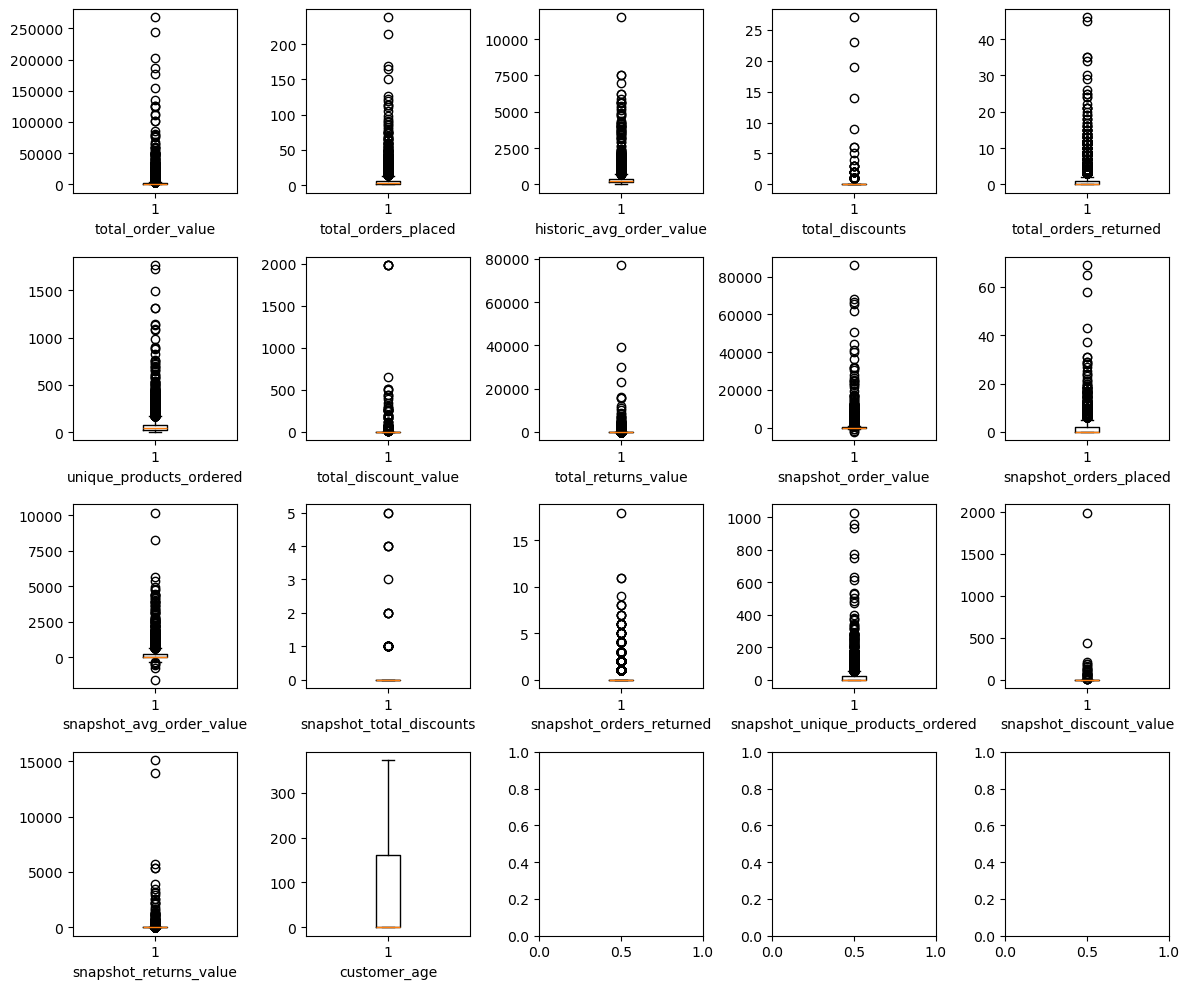

In [27]:
def boxplots(df, features):
    figure, axes = plt.subplots(4, 5, figsize=(12,10))
    axes = axes.flatten()

    i = 0
    for col in features:
        axes[i].boxplot(df[col])
        axes[i].set_xlabel(col)
        i += 1

    plt.tight_layout()
    plt.show()

boxplots(df, features)

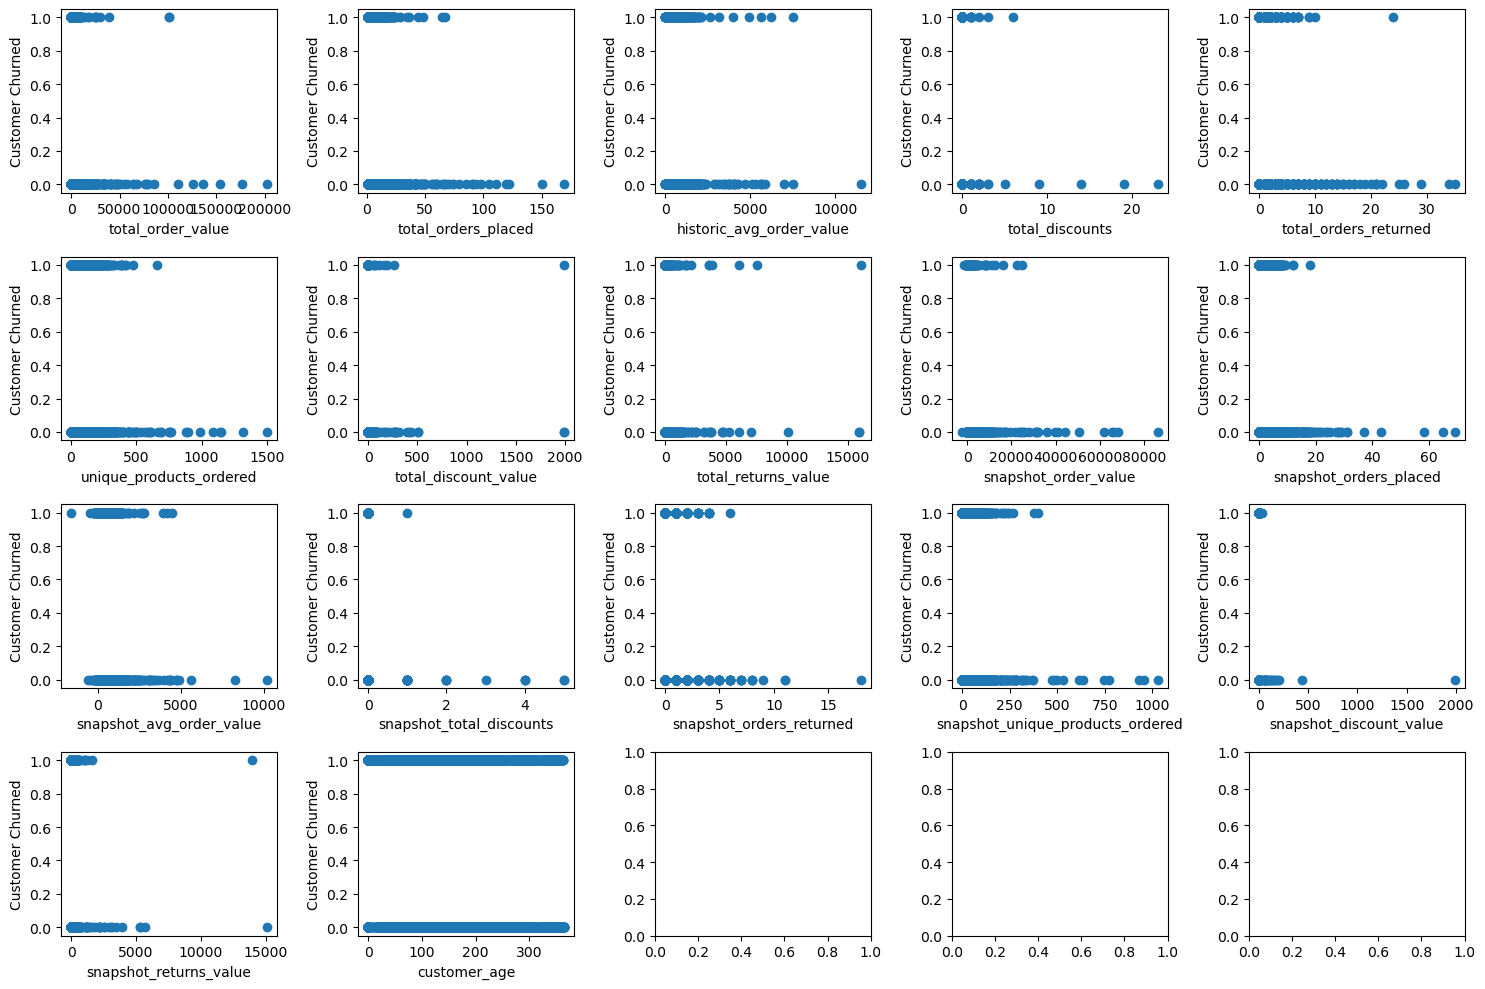

In [29]:
m,n = X_train.shape

figure, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

# Investigating collinearity

In [30]:
# Investigating colinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = df[features].copy()
x = x.astype(float)
x = add_constant(x)

df_vif = pd.DataFrame({
    'Feature' : x.columns,
    'VIF' : [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
})

df_vif = df_vif[df_vif['Feature'] != 'const'].reset_index(drop=True)

print(df_vif)

                             Feature       VIF
0                  total_order_value  2.767187
1                total_orders_placed  6.613312
2           historic_avg_order_value  1.629057
3                    total_discounts  2.071011
4              total_orders_returned  3.511814
5            unique_products_ordered  3.027351
6               total_discount_value  1.183234
7                total_returns_value  1.081146
8               snapshot_order_value  3.146068
9             snapshot_orders_placed  5.994072
10          snapshot_avg_order_value  2.514154
11          snapshot_total_discounts  2.063145
12          snapshot_orders_returned  2.654634
13  snapshot_unique_products_ordered  3.726868
14           snapshot_discount_value  1.204953
15            snapshot_returns_value  1.189524
16                      customer_age  1.765391


# Logistic Regression

Accuracy: 0.6696564562531732


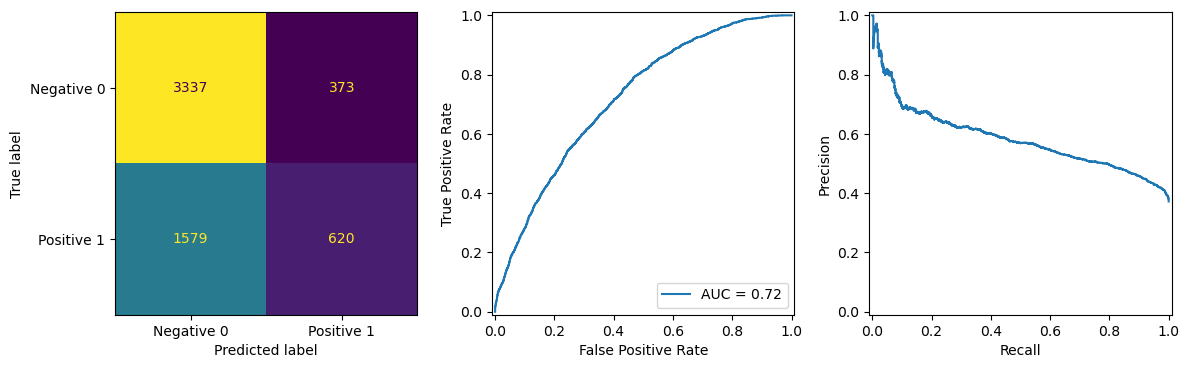

In [31]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

scaler = StandardScaler()
poly = PolynomialFeatures(degree=3)
model = linear_model.LogisticRegression(max_iter=2000, C=0.1, random_state=42)

def transform(X):
    X_poly = poly.fit_transform(X)
    X_poly_scaled = scaler.fit_transform(X_poly)

    return X_poly_scaled

# Transforming data
X_train_poly = transform(X_train)

# Training the model
model.fit(X_train_poly, y_train)

def evaluate(y, y_pred, y_proba):
    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = axes.flatten()

    print(f'Accuracy: {accuracy_score(y, y_pred)}')

    # Confusion Matrix
    matrix = confusion_matrix(y, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, 
                                        display_labels= ['Negative 0', 'Positive 1'])
    cm_display.plot(ax=axes[0], colorbar=False)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    roc_display.plot(ax=axes[1])

    # Precision Recall
    precision, recall, thresholds = precision_recall_curve(y, y_proba)
    pr_auc = auc(recall, precision)
    pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)
    pr_display.plot(ax=axes[2])

    plt.tight_layout()
    plt.show()

# Predicitions
y_pred_poly = model.predict(X_train_poly)
y_pred_poly_proba = model.predict_proba(X_train_poly)[:, 1]

# Evaluating model performance
evaluate(y_train, y_pred_poly, y_pred_poly_proba)

Accuracy: 0.4136


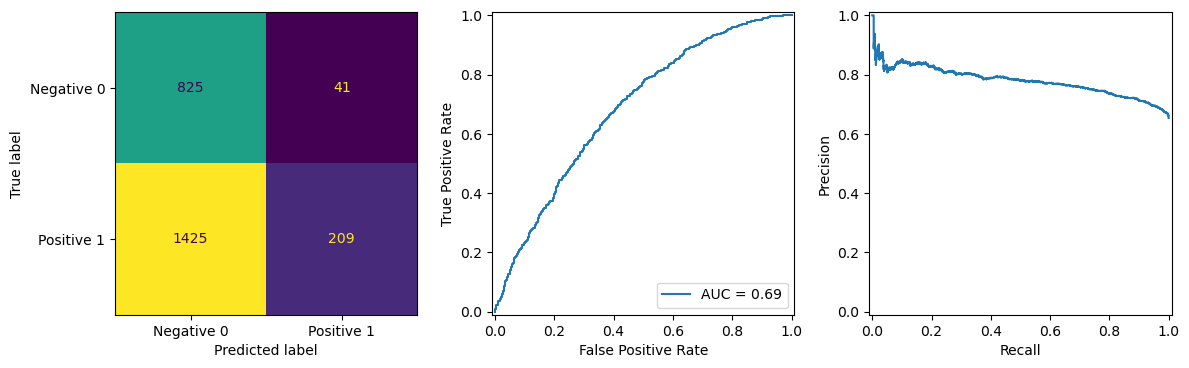

In [32]:
X_test_poly = poly.fit_transform(X_test)
X_test_poly = scaler.fit_transform(X_test_poly)
y_pred_poly = model.predict(X_test_poly)
y_proba = model.predict_proba(X_test_poly)[:, 1]

evaluate(y_test, y_pred_poly, y_proba)

# XGBoost Model

Accuracy: 0.646


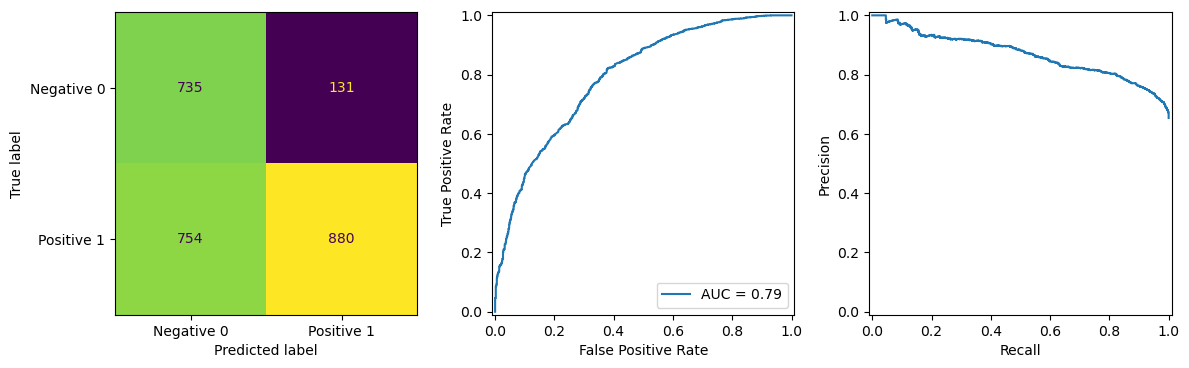

In [39]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators = 100, 
    max_depth = 4,
    learning_rate = 0.1,
    random_state = 42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

evaluate(y_test, y_pred, y_proba)

<Figure size 800x600 with 0 Axes>

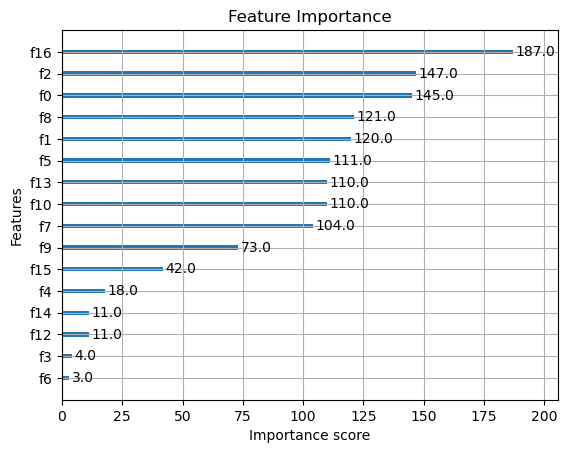

In [34]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()